# 11 — Source-type distribution (5 categories)

Each work in the corpus is assigned to one source-type bucket based on the
kind of evidence it provides about a contemporary social rule.

| Code | Category | Description | Examples |
|---|---|---|---|
| **A** | Legal / constitutional | Original legal text, statute, or constitutional clause quoted verbatim | Aristotle's *Athenian Constitution* |
| **B** | Court speech / oration | Court speech or oration invoking a specific extant law or procedure | The 10 Attic orators (Demosthenes, Lysias, Isaeus, Antiphon, Andocides, Aeschines, Hyperides, Dinarchus, Lycurgus, Demades) |
| **C** | Historical / biographical | Work composed by a historian or biographer | Plutarch, Thucydides, Polybius, Strabo, Pausanias, Appian, Athenaeus, Diogenes Laertius, Xenophon's *Agesilaus*, Lucian's biographical pieces |
| **D** | Contemporary treatise | Philosophical / political treatise implying the rule exists in the author's own society without quoting it | Aristotelian corpus outside the *Athenaion Politeia*, Platonic dialogues, Xenophon's treatises, Isocrates' epideictic essays, Plutarch's *Moralia*, Epictetus |
| **E** | Entertainment | Drama, satire, fiction; mixes commentary with artistic license | Aristophanes, Lucian's satirical pieces, Plutarch's *Sayings* |

**Corpus**: rebuilt inline using the same filters as notebook 03 (`03_authors_distribution.ipynb`) so the work count matches the 356-work corpus reported elsewhere. Historians are kept only when every polity they discuss falls in the Greek / Greco-Roman world; New Testament and Unknown authors are excluded.

**Sources**:
- `data/clean/perseus/perseus_works_wikidata.tsv` (metadata)
- `data/clean/final/works_factuality_v18.tsv` (factuality scores)
- `data/clean/classifications/works_polity_time_mapping_v2.json` (polity mapping)
- `scripts/classify_source_type.py` (classifier)

*Follows `notebook_rule.md`.*

## 1. Setup — imports, paths, constants

In [1]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

META_TSV     = Path('../data/clean/perseus/perseus_works_wikidata.tsv')
FACT_TSV     = Path('../data/clean/final/works_factuality_v18.tsv')
MAPPING_JSON = Path('../data/clean/classifications/works_polity_time_mapping_v2.json')

SCRIPTS_DIR = Path('../scripts').resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from classify_source_type import classify, CATEGORIES  # noqa: E402

CANONICAL_AUTHOR = {
    'tlg0062': 'Lucian of Samosata',
    'tlg0061': 'Pseudo-Lucian',
}

POLITY_TO_GROUP = {
    'Classical Greek poleis':                       'Greek',
    'Classical Athens':                             'Greek',
    'Classical Sparta':                             'Greek',
    'Classical Sparta and Peloponnesian League':    'Greek',
    'Classical Thebes':                             'Greek',
    'Classical Greek mercenary polis-world':        'Greek',
    'Archaic Greek poleis':                         'Greek',
    'Archaic Athens (Solonic)':                     'Greek',
    'Archaic Sparta':                               'Greek',
    'Greek philosophical tradition (pan-Hellenic)': 'Greek',
    'Hellenistic Greek philosophical schools':      'Greek',
    'Hellenistic Mediterranean':                    'Greek',
    'Hellenistic Kingdoms':                         'Greek',
    'Hellenistic kingdoms':                         'Greek',
    'Hellenistic Athens':                           'Greek',
    'Hellenistic Sparta':                           'Greek',
    'Hellenistic East':                             'Greek',
    'Macedonian Empire':                            'Greek',
    'Macedonian kingdom':                           'Greek',
    'Macedonian Empire (Successors)':               'Greek',
    'Diadochi Successor States':                    'Greek',
    'Antigonid Dynasty':                            'Greek',
    'Seleucid Empire':                              'Greek',
    'Ptolemaic Kingdom':                            'Greek',
    'Achaean League':                               'Greek',
    'Syracuse':                                     'Greek',
    'Syracuse (Hiero I)':                           'Greek',
    'Sicyon':                                       'Greek',
    'Epirus':                                       'Greek',
    'Corinth':                                      'Greek',
    'Greece':                                       'Greek',
    'Asia Minor':                                   'Greek',
    'Illyrian kingdoms':                            'Greek',
    'Mythological Athens':                          'Greek',
    'Mythological Greece':                          'Greek',
    'Mythological Greece (Odyssey)':                'Greek',
    'Roman Empire':                                 'Roman',
    'Roman Empire (Year of the Four Emperors)':     'Roman',
    'Roman Empire (Flavian)':                       'Roman',
    'Roman Empire (antiquarian)':                   'Roman',
    'Late Roman Republic':                          'Roman',
    'Middle Roman Republic':                        'Roman',
    'Early Roman Republic':                         'Roman',
    'Roman Republic':                               'Roman',
    'Roman Kingdom':                                'Roman',
    'Early Roman Kingdom':                          'Roman',
    'Rome':                                         'Roman',
    'Rome (antiquarian)':                           'Roman',
    'Italy':                                        'Roman',
    'Italic peoples':                               'Roman',
    'Samnite League':                               'Roman',
    'Volscians':                                    'Roman',
    'Gallic tribes':                                'Roman',
    'Carthage':                                     'Roman',
    'Kingdom of Numidia':                           'Roman',
    'Lusitania':                                    'Roman',
    'Celtiberian tribes':                           'Roman',
    'Pontic kingdom (Mithridates VI)':              'Roman',
    'Roman Empire (Hellenic culture)':              'Greco-Roman',
    'Roman Empire (Greece)':                        'Greco-Roman',
    'Roman Empire (Greece and Thrace)':             'Greco-Roman',
    'Roman Empire (Hellenic intellectual world)':   'Greco-Roman',
    'Achaemenid Empire':                            'Persian',
    'Achaemenid Empire (Cyrus the Great)':          'Persian',
    'Achaemenid Persia':                            'Persian',
    'Achaidmenid Empire':                           'Persian',
    'Lydia':                                        'Persian',
    'Pharaonic Egypt':                              'Ancient Near East',
    'Pharaonic Egypt (religious-mythic)':           'Ancient Near East',
    'Ancient Israel / Second Temple Judaism':       'Ancient Near East',
    'Judea':                                        'Ancient Near East',
    'Ancient Near East (mythic)':                   'Ancient Near East',
}
GREEK_GROUPS = {'Greek', 'Greco-Roman'}

SHORT_LABELS = {
    'A_legal_constitutional':  'A — Legal / constitutional (verbatim)',
    'B_oration':               'B — Court speech / oration',
    'C_historical':            'C — Historical / biographical',
    'D_contemporary_treatise': 'D — Contemporary treatise',
    'E_entertainment':         'E — Entertainment (drama, satire)',
    'F_religious_scriptural':  'F — Religious / scriptural (NT)',
}

MAIN_FIVE = [
    'A_legal_constitutional',
    'B_oration',
    'C_historical',
    'D_contemporary_treatise',
    'E_entertainment',
]

In [2]:
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'Helvetica',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'legend.frameon': False,
})

BAR = '#4a7a9b'

## 2. Load data

In [3]:
meta_raw = pd.read_csv(META_TSV, sep='\t')
fact_raw = pd.read_csv(FACT_TSV, sep='\t')[['perseus_id', 'factuality']]

for code, label in CANONICAL_AUTHOR.items():
    meta_raw.loc[meta_raw['author_code'] == code, 'perseus_author'] = label

with MAPPING_JSON.open() as f:
    polity_mapping = json.load(f)

print(f'Meta:       {len(meta_raw):,} works from {META_TSV.name}')
print(f'Factuality: {len(fact_raw):,} rows  from {FACT_TSV.name}')
print(f'Polity map: {len(polity_mapping):,} entries from {MAPPING_JSON.name}')

Meta:       1,096 works from perseus_works_wikidata.tsv
Factuality: 391 rows  from works_factuality_v18.tsv
Polity map: 181 entries from works_polity_time_mapping_v2.json


## 3. Build the 356-work corpus (mirrors notebook 03)

Filter sequence:
1. `selected_english_translation == 1`
2. `author_impact_date` present
3. Drop `factuality == 1` (mythic / tragic / speculative)
4. Historians: keep only works whose polities are entirely Greek / Greco-Roman
5. Drop New Testament and Unknown authors

In [4]:
df = meta_raw[meta_raw['selected_english_translation'] == 1].copy()
steps = [('Selected English', len(df))]

df['year'] = pd.to_numeric(df['author_impact_date'], errors='coerce')
df = df[df['year'].notna()].copy()
df['year'] = df['year'].astype(int)
df['n_pages'] = pd.to_numeric(df['n_pages'], errors='coerce').fillna(0).astype(int)
steps.append(('Require author year', len(df)))

df = df.merge(fact_raw, on='perseus_id', how='left')
df = df[df['factuality'] != 1].copy()
steps.append(('Drop factuality == 1 (mythic/tragic/speculative)', len(df)))

unmapped = set()
all_greek = {}
for file_id, v in polity_mapping.items():
    polities = [p.strip() for p in
                (v.get('mentioned_polities_in_work') or '').split(';')
                if p.strip()]
    groups = set()
    for p in polities:
        g = POLITY_TO_GROUP.get(p)
        if g is None:
            unmapped.add(p)
        else:
            groups.add(g)
    all_greek[file_id] = bool(groups) and groups.issubset(GREEK_GROUPS)
assert not unmapped, f'Unmapped polities: {sorted(unmapped)}'

df['greek_only'] = df['file_id'].map(all_greek).fillna(False)
n_before = len(df)
df = df[(df['historian'] != 1) | df['greek_only']].copy()
steps.append(('Historians: keep only entirely-Greek-world works '
              f'(dropped {n_before - len(df)} historian works)', len(df)))

author_norm = df['perseus_author'].astype(str).str.strip().str.lower()
df = df[~author_norm.isin({'new testament', 'unknown'})].copy()
steps.append(('Drop New Testament and Unknown', len(df)))

print('Row count after each step:')
for label, n in steps:
    print(f'  {label:<72s}  {n:,}')
print(f'\nFinal corpus: {len(df)} works | '
      f'{df["perseus_author"].nunique()} authors | '
      f'{df["n_pages"].sum():,} pages')

assert df['file_id'].is_unique, 'file_id is not unique'

Row count after each step:
  Selected English                                                          581
  Require author year                                                       581
  Drop factuality == 1 (mythic/tragic/speculative)                          508
  Historians: keep only entirely-Greek-world works (dropped 122 historian works)  386
  Drop New Testament and Unknown                                            356

Final corpus: 356 works | 33 authors | 20,478 pages


## 4. Apply the source-type classifier

In [5]:
n_before = len(df)
df['source_type'] = df.apply(classify, axis=1)
df['source_type_description'] = df['source_type'].map(CATEGORIES)

assert len(df) == n_before, f'lost rows during classification: {n_before} -> {len(df)}'
assert df['source_type'].notna().all(), 'unclassified rows present'

print(f'Classified {len(df):,} works into {df["source_type"].nunique()} buckets')
df[['perseus_author', 'perseus_title', 'source_type']].head()

Classified 356 works into 6 buckets


,perseus_author,perseus_title,source_type
0,Thucydides,The Peloponnesian War,C_historical
1,Diogenes Laertius,Lives of Eminent Philosophers,C_historical
21,Plutarch,Demosthenes,C_historical
26,Plutarch,Nicias,D_contemporary_treatise
27,Plutarch,Solon,C_historical


## 5. Counts table

In [6]:
all_codes = list(SHORT_LABELS)
counts = df['source_type'].value_counts().reindex(all_codes, fill_value=0)
total = int(counts.sum())

tbl = counts.to_frame('works')
tbl['%'] = (100 * tbl['works'] / total).round(1)
tbl['label'] = [SHORT_LABELS[c] for c in tbl.index]
tbl

,works,%,label
source_type,,,
A_legal_constitutional,1,0.3,A — Legal / constitutional (verbatim)
B_oration,136,38.2,B — Court speech / oration
C_historical,20,5.6,C — Historical / biographical
D_contemporary_treatise,136,38.2,D — Contemporary treatise
E_entertainment,57,16.0,"E — Entertainment (drama, satire)"
F_religious_scriptural,6,1.7,F — Religious / scriptural (NT)


## 6. Figures

### Figure 1: Source-type distribution (5 categories, by work)

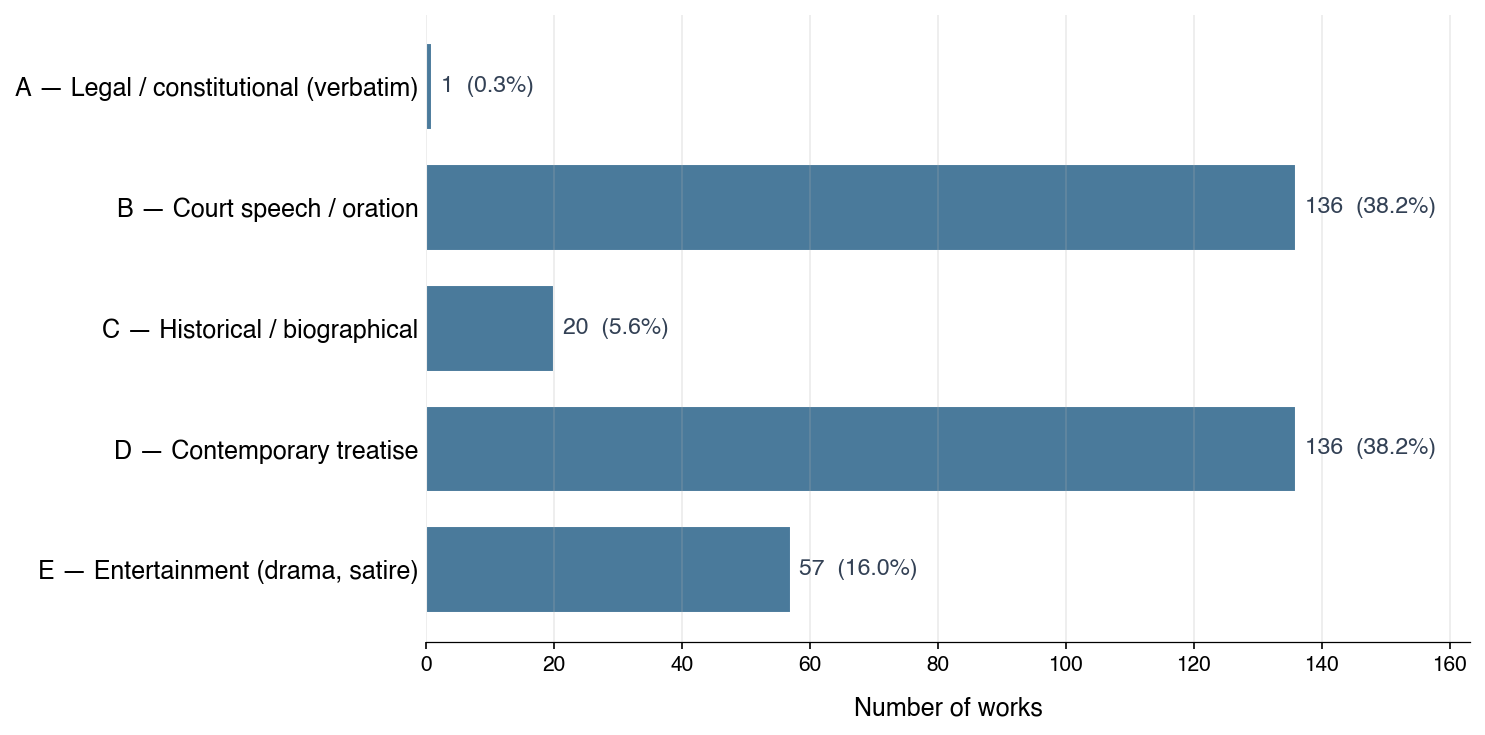

In [7]:
order = list(reversed(MAIN_FIVE))
labels = [SHORT_LABELS[c] for c in order]
values = [int(counts.get(c, 0)) for c in order]
y = list(range(len(order)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y, values, color=BAR, edgecolor='white', height=0.72)

for yi, v in zip(y, values):
    pct = v / total * 100 if total else 0
    ax.text(v + max(values) * 0.01, yi,
            f'{v:,}  ({pct:.1f}%)',
            va='center', fontsize=11, color='#334155')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Number of works', fontsize=12, labelpad=10)
ax.set_xlim(0, max(values) * 1.2)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right', 'left']].set_visible(False)
fig.tight_layout()

## 7. Authors per category (sanity check)

In [8]:
by_cat = (
    df.groupby('source_type')['perseus_author']
      .apply(lambda s: ', '.join(sorted(s.unique())))
      .reindex(all_codes)
)
for code, authors in by_cat.items():
    n = int(counts.get(code, 0))
    if n == 0:
        continue
    print(f'{SHORT_LABELS[code]}  (n={n})')
    print(f'  authors: {authors}')
    print()

A — Legal / constitutional (verbatim)  (n=1)
  authors: Aristotle

B — Court speech / oration  (n=136)
  authors: Aeschines, Andocides, Antiphon, Demades, Demosthenes, Dinarchus, Hyperides, Isaeus, Isocrates, Lycurgus, Lysias, Plato

C — Historical / biographical  (n=20)
  authors: Athenaeus, Diogenes Laertius, Lucian of Samosata, Pausanias, Plutarch, Thucydides

D — Contemporary treatise  (n=136)
  authors: Aretaeus of Cappadocia, Aristotle, Demosthenes, Epictetus, Euclid, Galen, Hippocrates, Isocrates, Lucian of Samosata, Plato, Plutarch, Pseudo-Lucian, Pseudo-Plutarch, Xenophon

E — Entertainment (drama, satire)  (n=57)
  authors: Aristophanes, Lucian of Samosata, Plutarch

F — Religious / scriptural (NT)  (n=6)
  authors: Barnabas, Clement of Rome, Hermas, Ignatius of Antioch, Polycarp



## 8. Persist the annotation

Add the source-type code as a new column **`work_factuality`** on the final
annotation dataset (`final_dataset_for_criteria.tsv`) and save back in place.
The classifier is row-wise, so it produces a label for every work in that
file regardless of corpus differences.

In [9]:
ANNOT_TSV = Path('../data/clean/final/final_dataset_for_criteria.tsv')

annot = pd.read_csv(ANNOT_TSV, sep='\t')
n_rows_before = len(annot)
cols_before = list(annot.columns)
print(f'Loaded {n_rows_before:,} rows × {len(cols_before)} cols from {ANNOT_TSV.name}')

annot['work_factuality'] = annot.apply(classify, axis=1)

assert len(annot) == n_rows_before, 'row count changed after annotation'
assert annot['work_factuality'].notna().all(), 'unclassified rows present'
assert annot['file_id'].is_unique, 'file_id is not unique'

print('\nDistribution of work_factuality on the annotation file:')
print(annot['work_factuality'].value_counts().to_string())
annot[['file_id', 'perseus_author', 'perseus_title', 'work_factuality']].head()

Loaded 328 rows × 23 cols from final_dataset_for_criteria.tsv

Distribution of work_factuality on the annotation file:
work_factuality
B_oration                  136
D_contemporary_treatise     98
E_entertainment             56
F_religious_scriptural      33
C_historical                 4
A_legal_constitutional       1


,file_id,perseus_author,perseus_title,work_factuality
0,tlg0027.tlg004.perseus-eng2,Andocides,Against Alcibiades,B_oration
1,tlg0027.tlg002.perseus-eng2,Andocides,On His Return,B_oration
2,tlg0027.tlg001.perseus-eng2,Andocides,On the Mysteries,B_oration
3,tlg0027.tlg003.perseus-eng2,Andocides,On the Peace with Sparta,B_oration
4,tlg0028.tlg006.perseus-eng2,Antiphon,On the Choreutes,B_oration


In [10]:
annot.to_csv(ANNOT_TSV, sep='\t', index=False)
added = [c for c in annot.columns if c not in cols_before]
print(f'Saved {len(annot):,} rows × {len(annot.columns)} cols → {ANNOT_TSV}')
print(f'New columns added: {added}')

Saved 328 rows × 24 cols → ../data/clean/final/final_dataset_for_criteria.tsv
New columns added: ['work_factuality']
